In [1]:

from SleepMReye.sleepmreye.sleep_mrio import SleepMRIO

mrio = SleepMRIO(
    bids_root="/Users/zach/2025_RA/matthias/bids_sleepmreye",
    exclude_subjects=["01", "07", "09", "12"],
    tr=2.1,
    task="sleep",
    load_signal=True,
    desc_add="clean-with-fd-clamped",
)


EOG data not full for 18, 1 (0/427). Skipping
EOG data not full for 18, 2 (0/427). Skipping
EOG data not full for 18, 3 (0/427). Skipping
EOG data not full for 18, 4 (0/427). Skipping
EOG data not full for 18, 5 (0/427). Skipping
EOG data not full for 16, 1 (282/427). Skipping
EOG data not full for 16, 2 (282/427). Skipping
EOG data not full for 16, 3 (293/427). Skipping
EOG data not full for 16, 4 (234/427). Skipping
EOG data not full for 16, 5 (237/427). Skipping
EOG data not full for 11, 5 (161/427). Skipping
EOG data not full for 23, 2 (0/427). Skipping
EOG data not full for 23, 3 (0/427). Skipping
EOG data not full for 15, 3 (151/427). Skipping


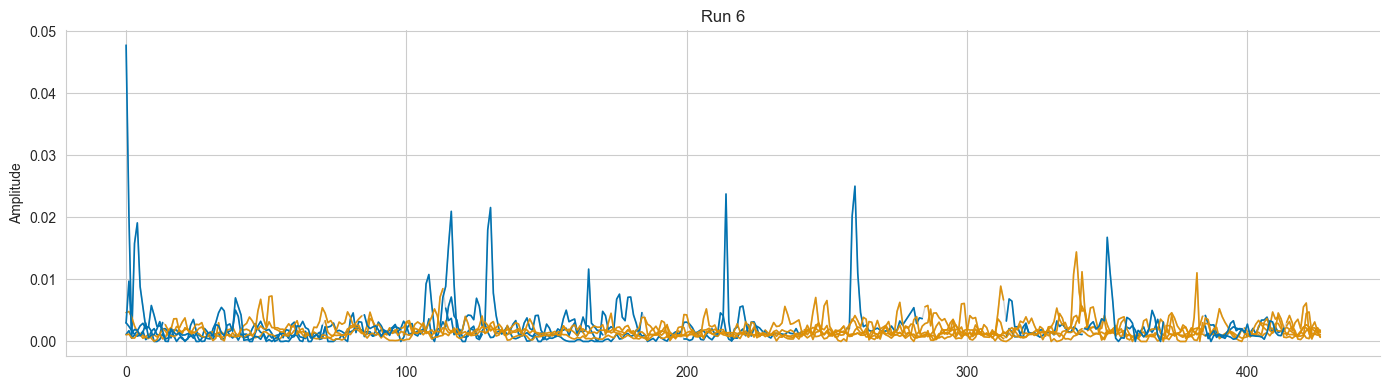

In [60]:
import numpy as np
from matplotlib import pyplot as plt

subject = "15"

state_colors = {
    'W': ("#0173b2ff", "Wake"),
    'S': ("#de8f05f2", "Sleep")
}


runs = [(run, run_df) for _, run, run_df in mrio.iter_run_events(subject=subject)]

max_amp = np.max([mrio.load_eye_move(subject, run[0])[0] for run in runs])
max_amp = np.max([run[1]["mreyemove"] for run in runs])
# fig, axes = plt.subplots(len(runs), 1, figsize=(14, 2 * len(runs)), sharex=False)
fig, axes = plt.subplots(figsize=(14, 4 ), sharex=False)

if len(runs) == 1:
    axes = [axes]

# for ax, (run, run_df) in zip(axes, runs):
for (run, run_df) in runs:
    ax = axes
    eye_signal, _ = mrio.load_eye_move(subject, run)
    # eye_signal[eye_signal == 0] = None
    # eye_signal = np.log(eye_signal)
    time = np.arange(len(eye_signal))

    ax.plot(time, eye_signal, color='lightgray', linewidth=1, zorder=1)

    for label, (color, name) in state_colors.items():
        if label not in run_df.columns:
            continue
        mask = run_df[label].values.astype(bool)
        masked_signal = np.where(mask, eye_signal, np.nan)
        ax.plot(time, masked_signal, color=color, linewidth=1.2, label=name, zorder=2)
    
    # ax.set_ylim([0, max_amp])
    ax.set_ylabel("Amplitude")
    ax.set_title(f"Run {run}")
    # ax.set_yscale("log")
    ax.spines[["top", "right"]].set_visible(False)

# Shared labels and legend
# axes[-1].set_xlabel("Functional Volumes")
# handles, labels = axes[0].get_legend_handles_labels()
# fig.legend(handles, labels, frameon=True)
# fig.suptitle(f"Eye movement signal — subject {subject}\n", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

In [6]:
import heapq

target_tr = 260
top_k = 5
candidates = []

for subject, run, run_df in mrio.iter_run_events():
  signal = run_df["mreyemove"].to_numpy()
  if np.isnan(signal).all():
      continue
  peak_tr = int(np.nanargmax(signal))
  dist = abs(peak_tr - target_tr)
  heapq.heappush(candidates, (dist, subject, run, peak_tr))

for dist, subj, run, peak in heapq.nsmallest(top_k, candidates):
  print(f"sub-{subj} run-{run}: peak at TR {peak} (off by {dist})")

sub-30 run-1: peak at TR 261 (off by 1)
sub-31 run-6: peak at TR 261 (off by 1)
sub-17 run-3: peak at TR 258 (off by 2)
sub-33 run-4: peak at TR 266 (off by 6)
sub-20 run-1: peak at TR 268 (off by 8)


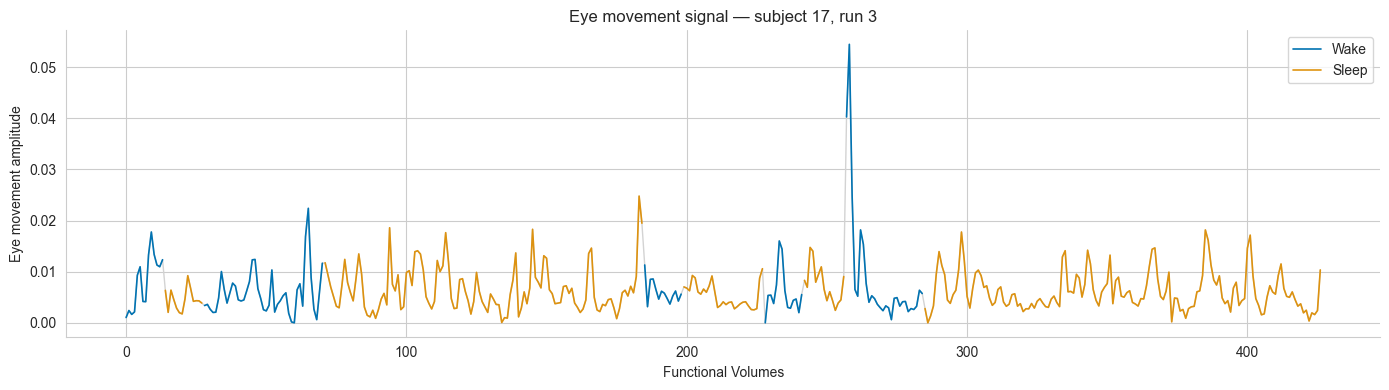

In [8]:

import numpy as np
from matplotlib import pyplot as plt

subject = "17"
run = 3

df = mrio.events
df = df[(df["subject"]==subject) & (df["run"]==run)]
eye_signal, _ = mrio.load_eye_move(subject, run)


fig, ax = plt.subplots(figsize=(14, 4))

time = np.arange(len(eye_signal))

# Plot full signal in gray as baseline
ax.plot(time, eye_signal, color='lightgray', linewidth=1, zorder=1)

# Overlay colored segments by state
state_colors = {
    'W': ("#0173b2ff", "Wake"),
    # '1': ("#E8A44C", "N1"),
    # '2': ("#6DBE6D", "N2"),
    'S': ("#de8f05f2", "Sleep")
}

for label, (color, name) in state_colors.items():
    if label not in df.columns:
        continue
    mask = df[label].values.astype(bool)
    # Plot only the masked timepoints
    masked_signal = np.where(mask, eye_signal, np.nan)
    ax.plot(time, masked_signal, color=color, linewidth=1.2, label=name, zorder=2)

ax.set_xlabel("Functional Volumes")
ax.set_ylabel("Eye movement amplitude")
ax.set_title(f"Eye movement signal — subject {subject}, run {run}")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()
fig.savefig("/Users/zach/2025_RA/matthias/final images/eye_voxels/ideal_run.svg", dpi=300)

In [37]:
np.random.uniform(1,3)

1.3243381798036422